In [ ]:
import os
import numpy as np
from scipy import interpolate
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

In [2]:
def normalize(seq):
    '''
    normalize to [-1,1]
    :param seq:
    :return:
    '''
    return 2*(seq-np.min(seq))/(np.max(seq)-np.min(seq))-1

def read_mocap_file(file_path):
    timeseries=[]
    with open(file_path,"r") as f:
        for line in f.readlines():
            x=line.strip().split(" ")
            timeseries.append([float(xx) for xx in x])
    timeseries=np.array(timeseries)
    for i in range(timeseries.shape[1]):
        timeseries[:,i]=normalize(timeseries[:,i])

    return timeseries

In [3]:
DATA_DIR = "BeatGAN/experiments/mocap/dataset"
WALK_NAMES = [f"35_{i:02d}" for i in range(1, 17)]
RUN_NAMES  = [f"35_{i:02d}" for i in range(17, 27)]

def load_all_files(names, subdir):
    data = {}
    for name in names:
        path = os.path.join(DATA_DIR, subdir, f"{name}.amc.4d")
        data[name] = read_mocap_file(path)  # (N_frames, 4), normalized to [-1, 1]
    return data

walk_data = load_all_files(WALK_NAMES, "walk")
run_data  = load_all_files(RUN_NAMES, "run")

print(f"Loaded {len(walk_data)} walk files, {len(run_data)} run files")
for name in list(walk_data.keys())[:2]:
    print(f"  {name}: {walk_data[name].shape}")

Loaded 16 walk files, 10 run files
  35_01: (358, 4)
  35_02: (406, 4)


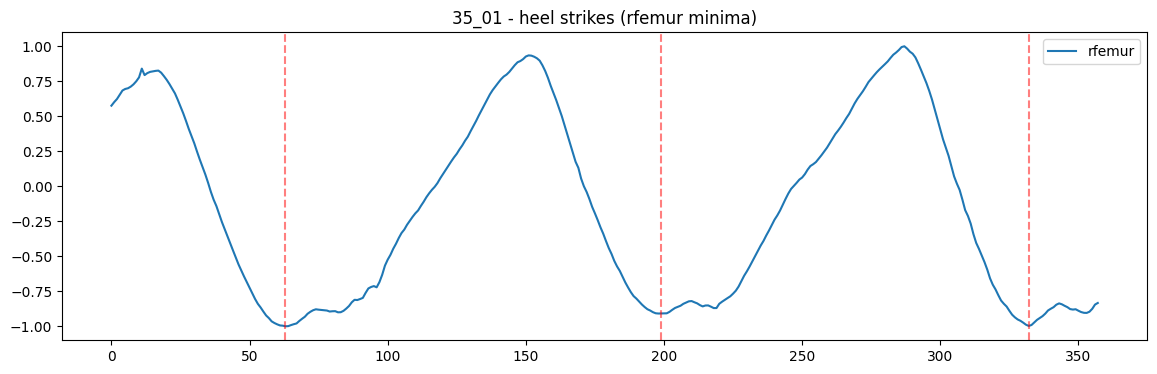

Detected 3 heel strikes


In [75]:
# Column 3 = rfemur (right femur angle)  most periodic during gait
import pandas as pd

COL_RFEMUR = 3
MIN_DISTANCE = 30  # minimum frames between heel strikes (prevents false positives)
smooth_window = 7  # window size for rolling mean smoothing

def detect_heel_strikes(data, col=COL_RFEMUR, distance=MIN_DISTANCE):
    """Find heel-strike frames (local minima of the signal)."""
    signal = data[:, col]
    s = pd.Series(signal)
    smooth = s.rolling(window=smooth_window, center=True).mean()  # Smooth the signal to reduce noise and improve peak detection
    peaks, _ = find_peaks(-smooth, distance=distance)  # minima of signal
    return peaks

# Visualize to verify detection looks correct
example_name = list(walk_data.keys())[0]
example_data = walk_data[example_name]
heel_strikes = detect_heel_strikes(example_data)

plt.figure(figsize=(14, 4))
plt.plot(example_data[:, COL_RFEMUR], label="rfemur")
for hs in heel_strikes:
    plt.axvline(hs, color='red', ls='--', alpha=0.5)
plt.title(f"{example_name} - heel strikes (rfemur minima)")
plt.legend()
plt.show()
print(f"Detected {len(heel_strikes)} heel strikes")

In [82]:
TARGET_LEN = 100  # frames per stride after resampling

def strides_from_file(data, target_len=TARGET_LEN):
    """Segment file data into strides, resample each to target_len."""
    heel_strikes = detect_heel_strikes(data)
    strides = []
    for i in range(len(heel_strikes) - 1):
        start, end = heel_strikes[i], heel_strikes[i + 1]
        stride = data[start:end, :]  # (orig_len, 4)
        # Resample via linear interpolation
        orig_len = stride.shape[0]
        old_x = np.arange(orig_len)
        new_x = np.linspace(0, orig_len - 1, target_len)
        f = interpolate.interp1d(old_x, stride, axis=0)
        resampled = f(new_x)  # (target_len, 4)
        strides.append(resampled)
    return np.array(strides)  # (N_strides, target_len, 4)

# Build tensor from all walk files
all_strides = []
for name, data in walk_data.items():
    strides = strides_from_file(data)
    all_strides.append(strides)

tensor = np.concatenate(all_strides, axis=0)
print(f"Tensor shape: {tensor.shape}")
print(f"  mode-1 (strides):    {tensor.shape[0]}")
print(f"  mode-2 (time):       {tensor.shape[1]}")
print(f"  mode-3 (features):   {tensor.shape[2]}")

Tensor shape: (38, 100, 4)
  mode-1 (strides):    38
  mode-2 (time):       100
  mode-3 (features):   4


In [83]:
tensor.shape

(38, 100, 4)

In [84]:
train_tensor = tensor[:30, :, :]
test_tensor = tensor[30:, :, :]
print(f"Train tensor shape: {train_tensor.shape}")
print(f"Test tensor shape: {test_tensor.shape}")

Train tensor shape: (30, 100, 4)
Test tensor shape: (8, 100, 4)


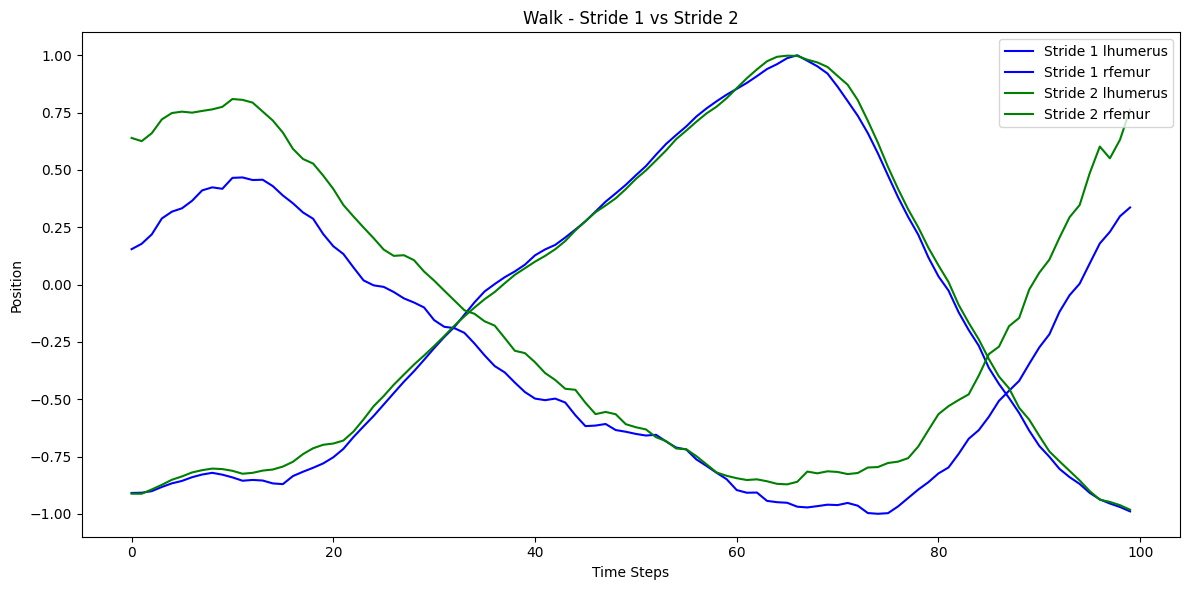

In [99]:
train_stride_1 = tensor[1, :, :]
train_stride_2 = tensor[10, :, :]

# day 1,3 merged
plt.figure(figsize=(12, 6))
plt.plot(train_stride_1[:, 0], label='Stride 1 lhumerus', color='blue')
plt.plot(train_stride_1[:, 3], label='Stride 1 rfemur', color='blue')
plt.plot(train_stride_2[:, 0], label='Stride 2 lhumerus', color='green')
plt.plot(train_stride_2[:, 3], label='Stride 2 rfemur', color='green')
plt.title('Walk - Stride 1 vs Stride 2')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

### Tensor Decomposition

In [94]:
from tensorly.decomposition import parafac

R = 2
weights, factors = parafac(train_tensor, rank=R, normalize_factors=True)

stride_factors, frame_factors, feature_factors = factors
print(f"Stride factors shape: {stride_factors.shape}")
print(f"Frames factors shape: {frame_factors.shape}")
print(f"Feature factors shape: {feature_factors.shape}")

Stride factors shape: (30, 2)
Frames factors shape: (100, 2)
Feature factors shape: (4, 2)


In [95]:
from tensorly import cp_to_tensor

# Reconstruct the tensor
reconstructed_tensor = cp_to_tensor((weights, factors))

# Or without weights (if normalize_factors=True, weights contain the norms)
# reconstructed_tensor = cp_to_tensor(factors)  # this ignores weights

print(f"Original tensor shape: {train_tensor.shape}")
print(f"Reconstructed tensor shape: {reconstructed_tensor.shape}")

Original tensor shape: (30, 100, 4)
Reconstructed tensor shape: (30, 100, 4)


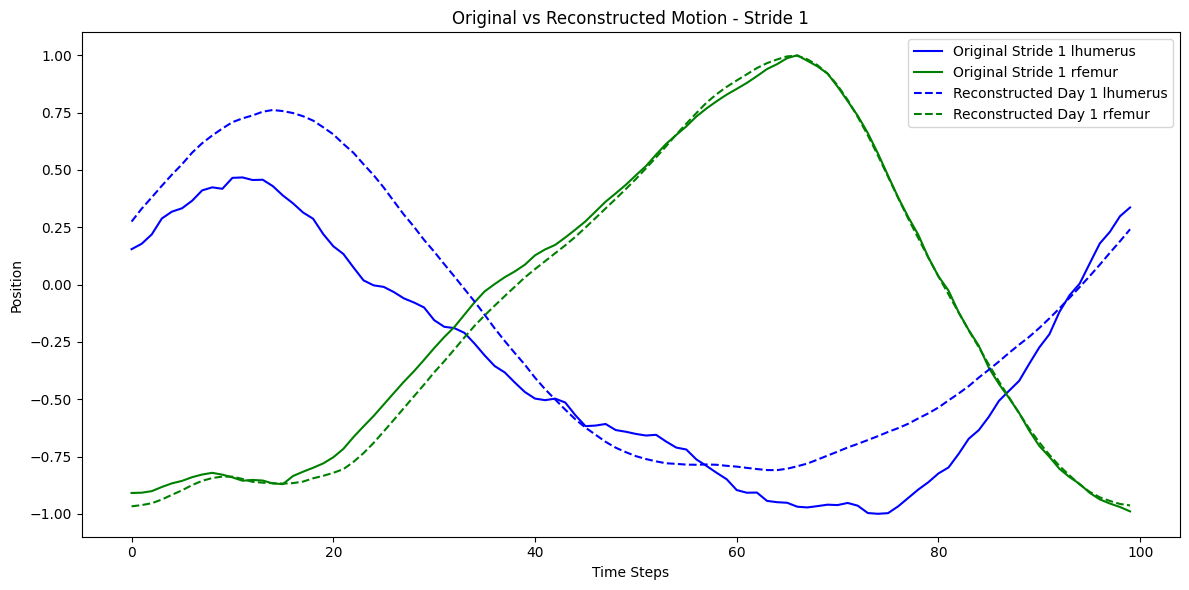

In [101]:
train_day_1_reconstructed = reconstructed_tensor[1, :, :]

plt.figure(figsize=(12, 6))
plt.plot(train_stride_1[:, 0], label='Original Stride 1 lhumerus', color='blue')
plt.plot(train_stride_1[:, 3], label='Original Stride 1 rfemur', color='green')
plt.plot(train_day_1_reconstructed[:, 0], label='Reconstructed Day 1 lhumerus', color='blue', linestyle='dashed')
plt.plot(train_day_1_reconstructed[:, 3], label='Reconstructed Day 1 rfemur', color='green', linestyle='dashed')
plt.title('Original vs Reconstructed Motion - Stride 1')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

### Tensor AR

In [107]:
N_strides = tensor.shape[0]
N_frames = tensor.shape[1]
N_features = tensor.shape[2]
N_train_strides = train_tensor.shape[0]
N_test_strides = test_tensor.shape[0]

In [103]:
from statsmodels.tsa.ar_model import AutoReg

forecast_stride_factors = np.zeros((N_test_strides, R))
for r in range(R):
    series = stride_factors[:, r]
    model = AutoReg(series, lags=1, old_names=False)
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=N_test_strides)
    forecast_stride_factors[:, r] = forecast

# Reconstruct forecast tensor
forecast_tensor = np.zeros((N_test_strides, N_frames, N_features))
for i in range(N_test_strides):
    for r in range(R):
        forecast_tensor[i, :, :] += weights[r] * np.outer(forecast_stride_factors[i, r] * frame_factors[:, r], feature_factors[:, r])

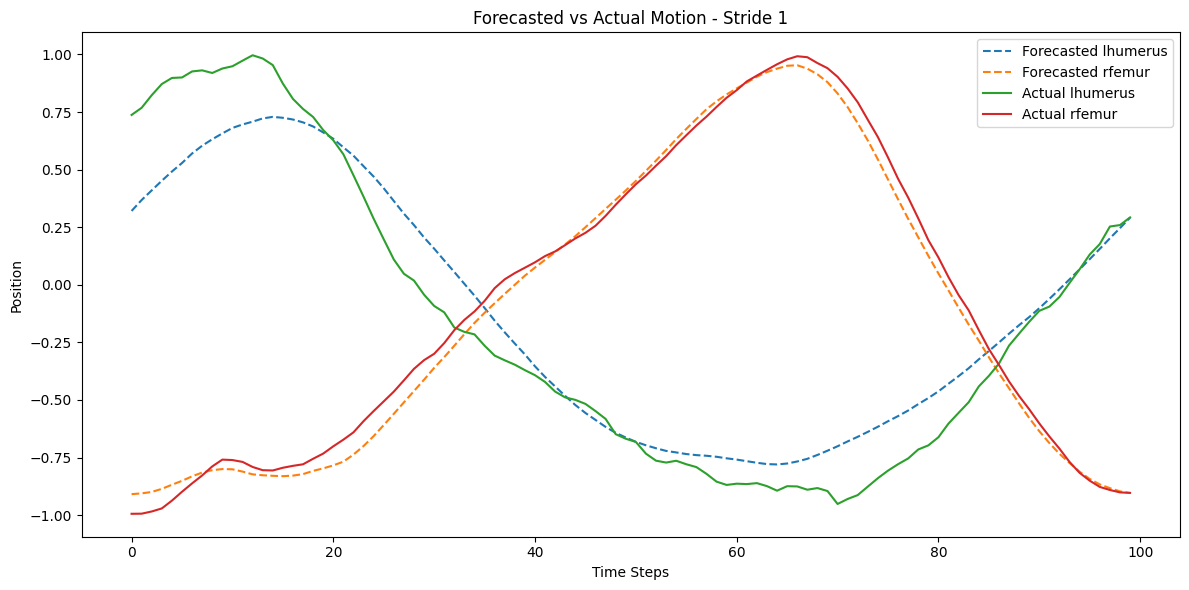

In [ ]:
forecasted_stride_1 = forecast_tensor[0, :, :]

forecasted_stride_1_lhumerus = forecasted_stride_1[:, 0]
forecasted_stride_1_rfemur = forecasted_stride_1[:, 3]

test_stride_1 = tensor[30, :, :]
test_stride_1_lhumerus = test_stride_1[:, 0]
test_stride_1_rfemur = test_stride_1[:, 3]

plt.figure(figsize=(12, 6))
plt.plot(forecasted_stride_1_lhumerus, label='Forecasted lhumerus', linestyle='--')
plt.plot(forecasted_stride_1_rfemur, label='Forecasted rfemur', linestyle='--')
plt.plot(test_stride_1_lhumerus, label='Actual lhumerus')
plt.plot(test_stride_1_rfemur, label='Actual rfemur')
plt.title('Forecasted vs Actual Motion - Stride 1')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

In [109]:
fc_flat = forecast_tensor.reshape(-1,4)
ac_flat = test_tensor.reshape(-1,4)
fc_flat.shape, ac_flat.shape

((800, 4), (800, 4))

/tmp/ipykernel_10659/2593934102.py:17: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10659/2593934102.py:17: UserWarning: Glyph 148 (\x94) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/kibria/Desktop/SPL3/env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kibria/Desktop/SPL3/env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 148 (\x94) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


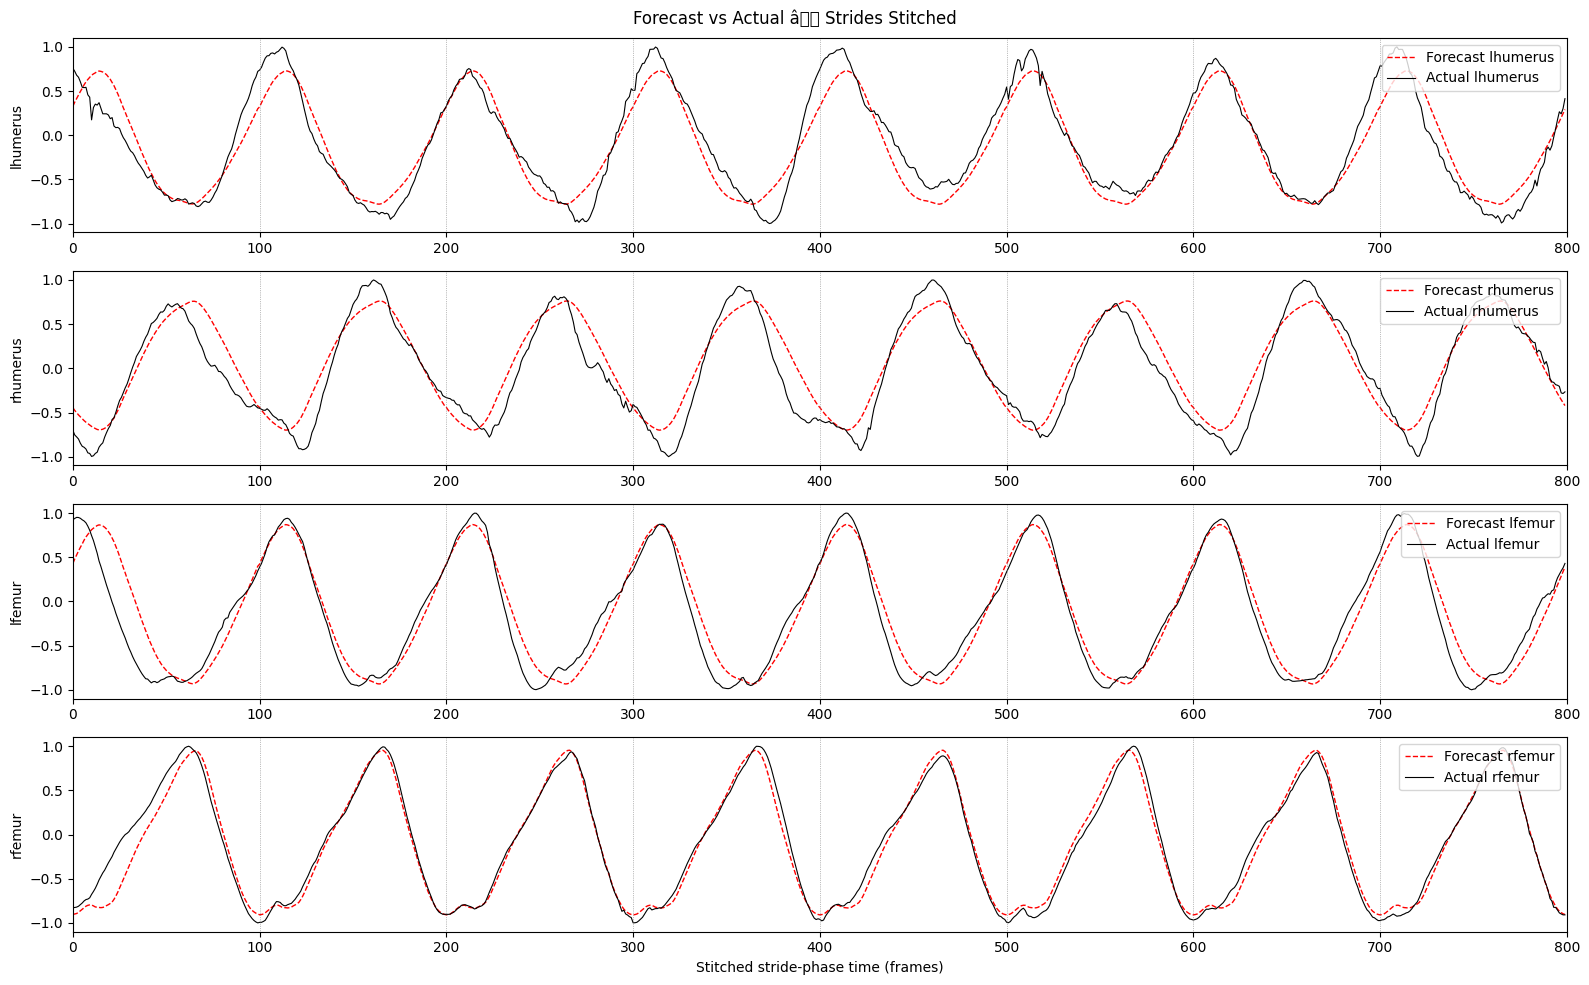

In [111]:
x = np.arange(fc_flat.shape[0])
plt.figure(figsize=(16, 10))
legends = ["lhumerus", "rhumerus", "lfemur", "rfemur"]

for i in range(4):
    plt.subplot(4, 1, i + 1)
    plt.plot(x, fc_flat[:, i], 'r--', lw=1, label=f'Forecast {legends[i]}')
    plt.plot(x, ac_flat[:, i], 'k-', lw=0.8, label=f'Actual {legends[i]}')
    for s in range(1, N_test_strides):
        plt.axvline(s * 100, color='gray', ls=':', lw=0.5)
    plt.ylabel(legends[i])
    plt.legend(loc='upper right')
    plt.xlim(0, fc_flat.shape[0])

plt.xlabel("Stitched stride-phase time (frames)")
plt.suptitle("Forecast vs Actual â Strides Stitched")
plt.tight_layout()
plt.show()

### Accuracy Analysis

In [119]:
from sklearn.metrics import r2_score

r2_per_feature = [r2_score(ac_flat[:, i], fc_flat[:, i]) for i in range(4)]
for i, feature in enumerate(legends):
    print(f"R^2 for {feature}: {r2_per_feature[i]:.4f}")

avg_r2 = np.mean(r2_per_feature)
print(f"Average R^2: {avg_r2:.4f}")

R^2 for lhumerus: 0.8874
R^2 for rhumerus: 0.8658
R^2 for lfemur: 0.9081
R^2 for rfemur: 0.9702
Average R^2: 0.9079
